# Notebook support pour projet ML modèle supervisé (Classification)
## NoteBook 4 - Tests d'autres modèles

Commençons par charger les données de sorties de la phase de Feature Engineering. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import sys
from pathlib import Path


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_predict,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
)

sys.path.append(str(Path.cwd().parent))

import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

df_MODEL = pd.read_csv("../data/processed/df_MODEL.csv")


## Séparation jeu de données en : Train/Test (90%) pour CV + Test final (10%)

**N.B :** Ici nous prenons notre travail de feature engineering en compte.

In [4]:
# 1. Split final sanctuarise
target = "a_quitte_l_entreprise"

X = df_MODEL.drop(columns=[target, "id_employee"])
y = df_MODEL[target]

X_model, X_final_test, y_model, y_final_test = train_test_split(X,y,test_size=0.10,random_state=42,stratify=y,)

print("X_model      :", X_model.shape)
print("X_final_test :", X_final_test.shape)
print("y_model      :", y_model.shape)
print("y_final_test :", y_final_test.shape)

X_model      : (1323, 53)
X_final_test : (147, 53)
y_model      : (1323,)
y_final_test : (147,)


## Tests autres modèles que baseline

Selon les recommandations de choix dans la documentation SKLEARN nous décidons de tester les modèles suivants :  
- Linear SVC,  
- Kneighbors classifier,  
- SV,  
- Ensemble classifiers (Random Forest, Gradient Bossting, et Adaboost),
- + on reprend Logistic regression.


Logistic Regression
Train | Accuracy: 0.9106 +/- 0.0051 | Precision: 0.8393 +/- 0.0273 | Recall: 0.5505 +/- 0.0201 | F1: 0.6647 +/- 0.0206 | ROC AUC: 0.8829 +/- 0.0058
Test  | Accuracy: 0.8859 +/- 0.0095 | Precision: 0.7323 +/- 0.0650 | Recall: 0.4689 +/- 0.0841 | F1: 0.5658 +/- 0.0555 | ROC AUC: 0.8429 +/- 0.0228


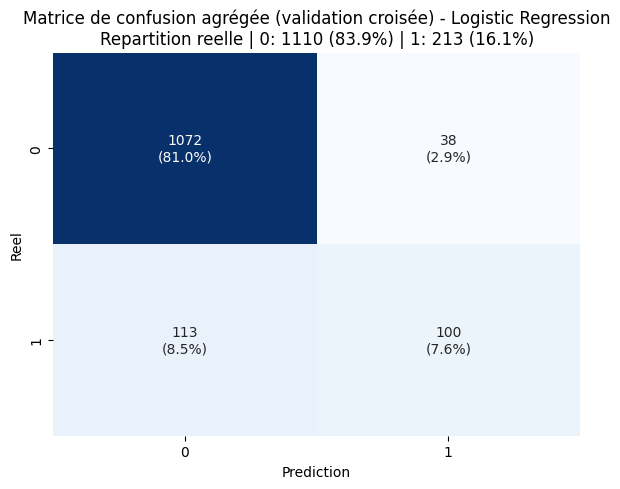


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      1110
         1.0       0.72      0.47      0.57       213

    accuracy                           0.89      1323
   macro avg       0.81      0.72      0.75      1323
weighted avg       0.88      0.89      0.88      1323


Linear SVC
Train | Accuracy: 0.9072 +/- 0.0048 | Precision: 0.8516 +/- 0.0185 | Recall: 0.5129 +/- 0.0251 | F1: 0.6400 +/- 0.0233 | ROC AUC: 0.8827 +/- 0.0060
Test  | Accuracy: 0.8790 +/- 0.0116 | Precision: 0.7198 +/- 0.0720 | Recall: 0.4079 +/- 0.0565 | F1: 0.5190 +/- 0.0588 | ROC AUC: 0.8422 +/- 0.0208


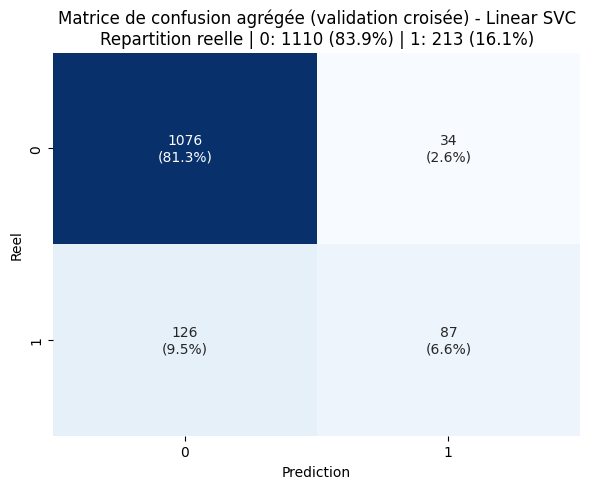


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.93      1110
         1.0       0.72      0.41      0.52       213

    accuracy                           0.88      1323
   macro avg       0.81      0.69      0.73      1323
weighted avg       0.87      0.88      0.86      1323


SVC
Train | Accuracy: 0.9271 +/- 0.0024 | Precision: 0.9895 +/- 0.0003 | Recall: 0.5528 +/- 0.0148 | F1: 0.7092 +/- 0.0123 | ROC AUC: 0.9730 +/- 0.0045
Test  | Accuracy: 0.8745 +/- 0.0135 | Precision: 0.8779 +/- 0.1611 | Recall: 0.2577 +/- 0.0695 | F1: 0.3943 +/- 0.0899 | ROC AUC: 0.8291 +/- 0.0137


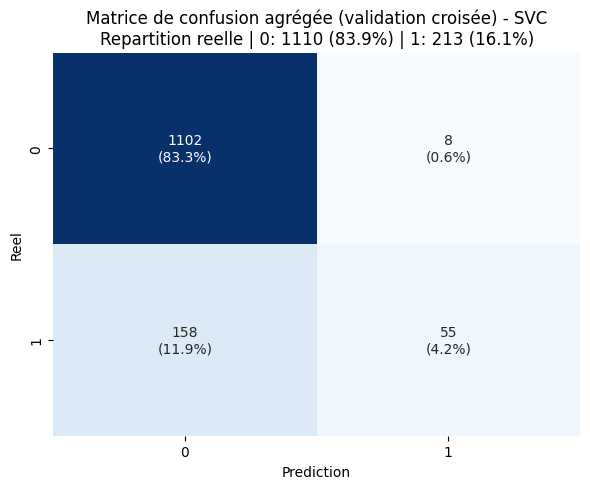


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.93      1110
         1.0       0.87      0.26      0.40       213

    accuracy                           0.87      1323
   macro avg       0.87      0.63      0.66      1323
weighted avg       0.87      0.87      0.84      1323


KNeighbors Classifier
Train | Accuracy: 0.8787 +/- 0.0075 | Precision: 0.8620 +/- 0.0341 | Recall: 0.2923 +/- 0.0426 | F1: 0.4354 +/- 0.0510 | ROC AUC: 0.9237 +/- 0.0086
Test  | Accuracy: 0.8534 +/- 0.0088 | Precision: 0.6902 +/- 0.1389 | Recall: 0.1547 +/- 0.0432 | F1: 0.2519 +/- 0.0663 | ROC AUC: 0.7140 +/- 0.0439


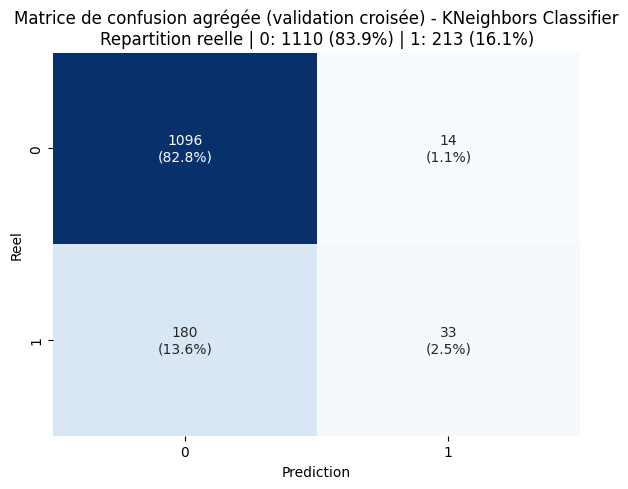


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92      1110
         1.0       0.70      0.15      0.25       213

    accuracy                           0.85      1323
   macro avg       0.78      0.57      0.59      1323
weighted avg       0.83      0.85      0.81      1323


Decision Tree
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.7589 +/- 0.0324 | Precision: 0.3058 +/- 0.0603 | Recall: 0.3795 +/- 0.0852 | F1: 0.3351 +/- 0.0618 | ROC AUC: 0.6055 +/- 0.0385


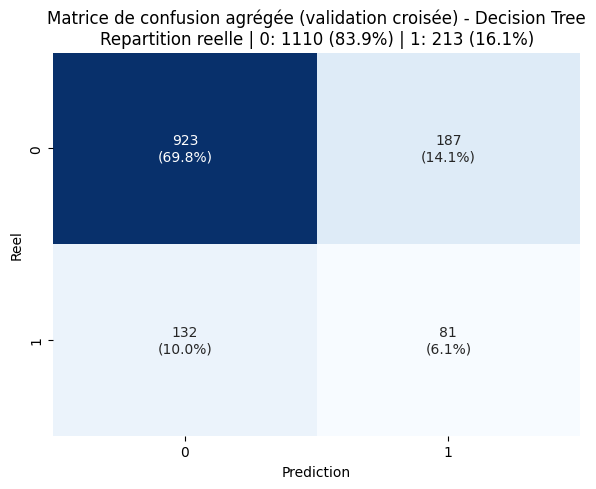


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.83      0.85      1110
         1.0       0.30      0.38      0.34       213

    accuracy                           0.76      1323
   macro avg       0.59      0.61      0.59      1323
weighted avg       0.78      0.76      0.77      1323


Random Forest
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8503 +/- 0.0071 | Precision: 0.6773 +/- 0.1689 | Recall: 0.1409 +/- 0.0620 | F1: 0.2264 +/- 0.0846 | ROC AUC: 0.8051 +/- 0.0378


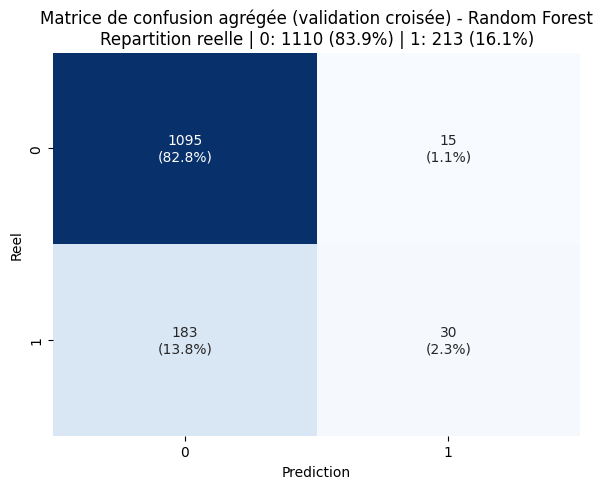


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92      1110
         1.0       0.67      0.14      0.23       213

    accuracy                           0.85      1323
   macro avg       0.76      0.56      0.57      1323
weighted avg       0.83      0.85      0.81      1323


Extra Trees
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8639 +/- 0.0166 | Precision: 0.7668 +/- 0.2315 | Recall: 0.2058 +/- 0.0952 | F1: 0.3186 +/- 0.1322 | ROC AUC: 0.8081 +/- 0.0303


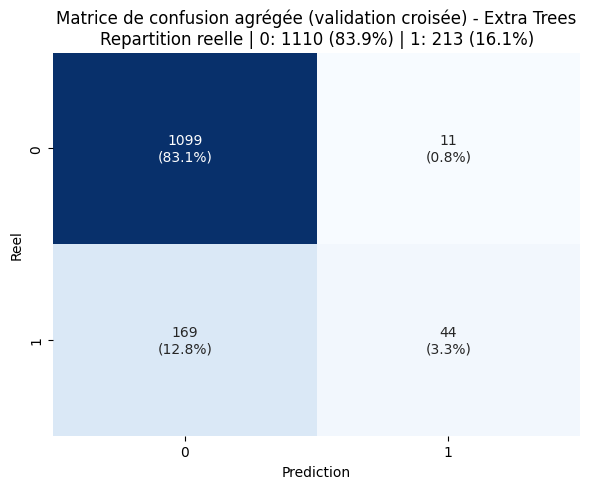


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92      1110
         1.0       0.80      0.21      0.33       213

    accuracy                           0.86      1323
   macro avg       0.83      0.60      0.63      1323
weighted avg       0.86      0.86      0.83      1323


Gradient Boosting
Train | Accuracy: 0.9633 +/- 0.0037 | Precision: 0.9985 +/- 0.0031 | Recall: 0.7735 +/- 0.0224 | F1: 0.8715 +/- 0.0144 | ROC AUC: 0.9923 +/- 0.0019
Test  | Accuracy: 0.8730 +/- 0.0133 | Precision: 0.7382 +/- 0.1087 | Recall: 0.3281 +/- 0.0822 | F1: 0.4491 +/- 0.0888 | ROC AUC: 0.8123 +/- 0.0296


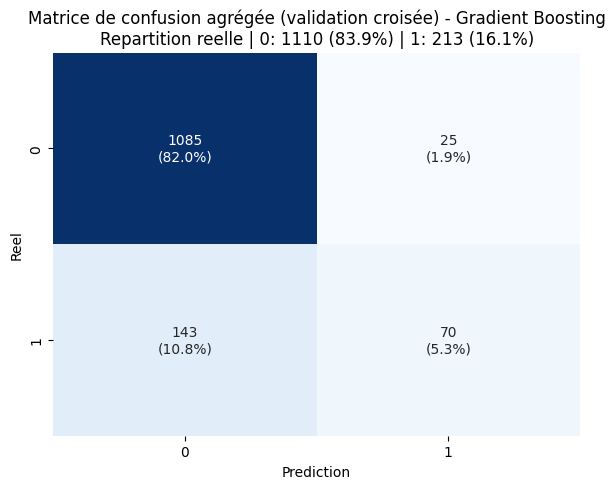


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      1110
         1.0       0.74      0.33      0.45       213

    accuracy                           0.87      1323
   macro avg       0.81      0.65      0.69      1323
weighted avg       0.86      0.87      0.85      1323


AdaBoost
Train | Accuracy: 0.8923 +/- 0.0092 | Precision: 0.8370 +/- 0.0314 | Recall: 0.4108 +/- 0.0549 | F1: 0.5493 +/- 0.0517 | ROC AUC: 0.9044 +/- 0.0093
Test  | Accuracy: 0.8791 +/- 0.0080 | Precision: 0.7800 +/- 0.0270 | Recall: 0.3472 +/- 0.0724 | F1: 0.4758 +/- 0.0702 | ROC AUC: 0.8155 +/- 0.0228


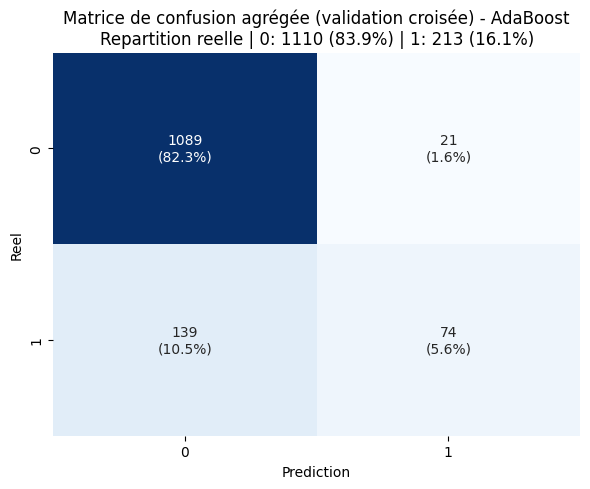


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93      1110
         1.0       0.78      0.35      0.48       213

    accuracy                           0.88      1323
   macro avg       0.83      0.66      0.71      1323
weighted avg       0.87      0.88      0.86      1323



In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),

    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, dual="auto", max_iter=5000)),
    ]),

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42)),
    ]),

    "KNeighbors Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42,
    ),
}


for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_model,y=y_model,cv=5,stratify=True,model_name=name,)

Pour la suite de l’analyse, nous retenons un modèle représentatif de chacune des grandes familles testées :  
- la régression logistique pour les modèles linéaires,  
- extra tree pour les modèles à base d’arbre,  
- AdaBoost pour les modèles d’ensemble.  

Cette sélection permet de comparer des approches de nature différente, d’en optimiser les paramètres, puis d’en analyser les performances et l’interprétabilité avant de retenir un modèle final.


Le réglage du seuil intervient après l’optimisation des hyperparamètres, car ces derniers modifient les scores prédits par le modèle et peuvent donc déplacer le seuil optimal. 
Il est donc plus rigoureux d’optimiser d’abord les modèles pré-sélectionnés, puis d’ajuster le seuil sur la version finale retenue.

In [6]:
import importlib
import src.Fonctions_MODEL as Fonctions_MODEL
importlib.reload(Fonctions_MODEL)

# 1. Logistic Regression
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["lbfgs"],
}

logreg_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=logreg_model,
    param_grid=logreg_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="grid",
    model_name="Logistic Regression",
)



Logistic Regression
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5703
Meilleurs hyperparametres : {'model__C': 0.1, 'model__class_weight': None, 'model__solver': 'lbfgs'}


In [7]:
# 2. Extra Trees
extratrees_model = ExtraTreesClassifier(random_state=42)

extratrees_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"],
}

extratrees_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=extratrees_model,
    param_grid=extratrees_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="random",
    n_iter=20,
    model_name="Extra Trees",
)


Extra Trees
RandomizedSearchCV | Scoring : f1 | Meilleur score CV : 0.5281
Meilleurs hyperparametres : {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'class_weight': 'balanced'}


In [8]:
# 3. AdaBoost
ada_model = AdaBoostClassifier(random_state=42)

ada_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
}

ada_results = Fonctions_MODEL.optimize_classification_hyperparameters(
    model=ada_model,
    param_grid=ada_param_grid,
    X=X_model,
    y=y_model,
    cv=5,
    scoring="f1",
    stratify=True,
    search_type="grid",
    model_name="AdaBoost",
)


AdaBoost
GridSearchCV | Scoring : f1 | Meilleur score CV : 0.5345
Meilleurs hyperparametres : {'learning_rate': 1.0, 'n_estimators': 300}


Faisons maintenant le travail de réglages de seuil sur les modèles retenus : 


Logistic Regression
Precision moyenne : 0.6283 | Meilleur seuil (max F1) : 0.3482
Au seuil 0.3482 | Precision test : 0.7500 | Recall test : 0.5581 | F1 test : 0.6400


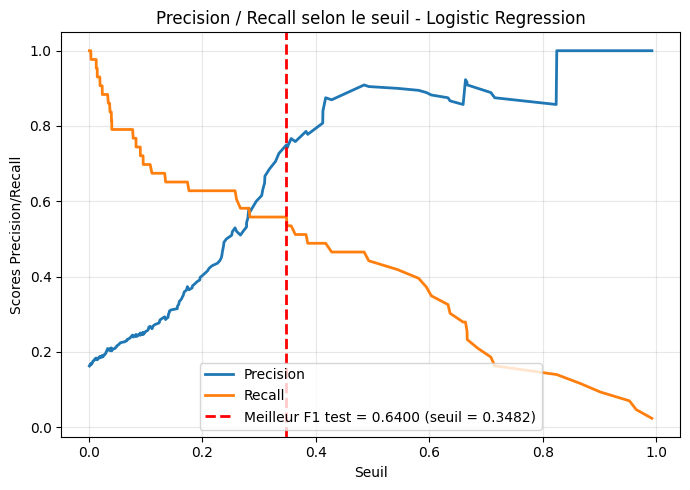


Extra Tree
Precision moyenne : 0.4714 | Meilleur seuil (max F1) : 0.5259
Au seuil 0.5259 | Precision test : 0.5641 | Recall test : 0.5116 | F1 test : 0.5366


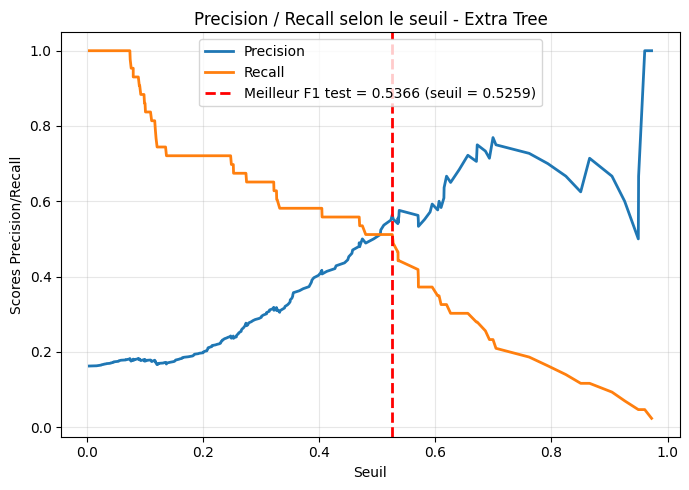


AdaBoost
Precision moyenne : 0.6342 | Meilleur seuil (max F1) : 0.4943
Au seuil 0.4943 | Precision test : 0.7500 | Recall test : 0.5581 | F1 test : 0.6400


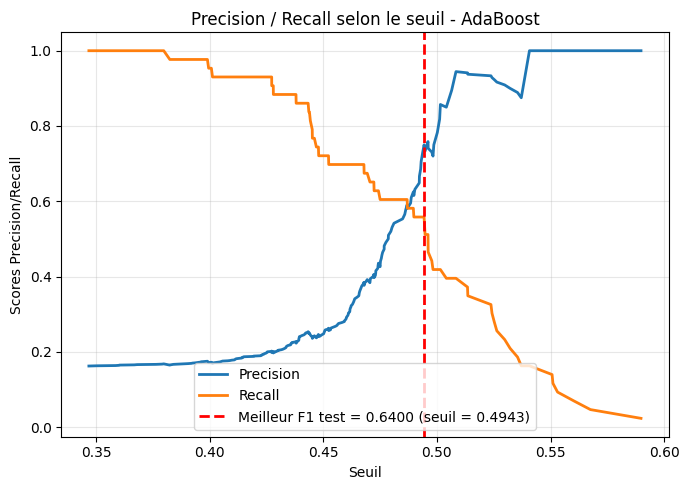

In [9]:
# Split interne pour le reglage du seuil
X_train_pr, X_valid_pr, y_train_pr, y_valid_pr = train_test_split(X_model,y_model,test_size=0.2,random_state=42,stratify=y_model,)

models = {
    "Logistic Regression": logreg_results["Best Estimator"],
    "Extra Tree": extratrees_results["Best Estimator"],
    "AdaBoost": ada_results["Best Estimator"],
}

threshold_results = {}

for name, model in models.items():
    threshold_results[name] = Fonctions_MODEL.evaluate_precision_recall_threshold(
        model=model,
        X_train=X_train_pr,
        y_train=y_train_pr,
        X_eval=X_valid_pr,
        y_eval=y_valid_pr,
        model_name=name,
        plot_curve=True,
    )


Le réglage du seuil confirme que Extra Tree reste nettement moins performant que les deux autres modèles retenus.  
À l’inverse, la régression logistique et AdaBoost atteignent ici des performances identiques sur le jeu de validation, avec un score F1 de 0.6400.  
Dans ce contexte, la régression logistique conserve toutefois un avantage méthodologique : à performance équivalente, elle reste plus simple, plus stable et plus interprétable qu’un modèle d’ensemble.  

Néanmoins nous décidons de conserver encore les deux modèles pour l'interprétation du feature importance global et local. 

,Variable,Coefficient,Abs_Coefficient
10,heure_supplementaires,0.819900,0.819900
17,annee_experience_totale_log,-0.498479,0.498479
2,nombre_experiences_precedentes,0.453361,0.453361
3,satisfaction_employee_environnement,-0.443355,0.443355
23,ratio_anciennete_poste,-0.374123,0.374123
20,annees_depuis_la_derniere_promotion_log,0.365757,0.365757
6,satisfaction_employee_nature_travail,-0.365696,0.365696
38,frequence_deplacement_Aucun,-0.320910,0.320910
39,frequence_deplacement_Frequent,0.297836,0.297836
8,satisfaction_employee_equilibre_pro_perso,-0.290907,0.290907


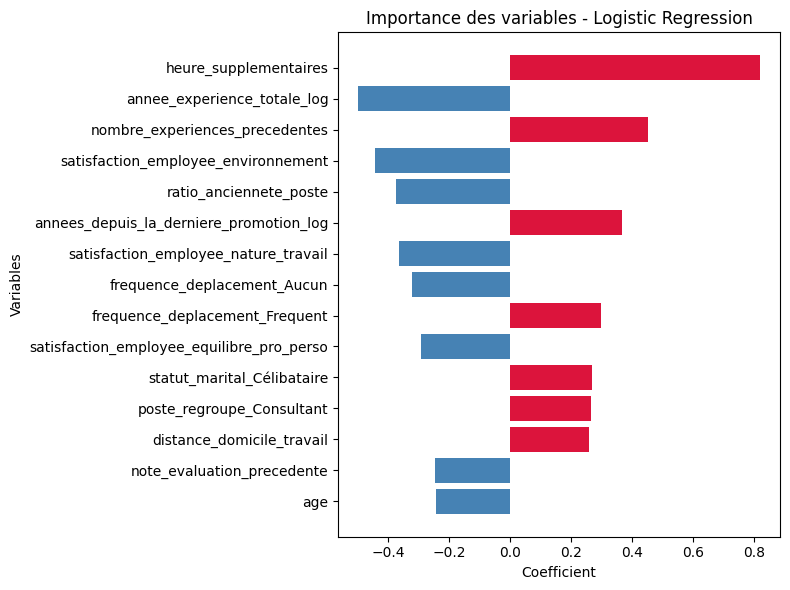

In [10]:
logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_model, y_model)

coef_df = pd.DataFrame({
    "Variable": X_model.columns,
    "Coefficient": logreg_best.named_steps["model"].coef_[0],
})

coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs_Coefficient", ascending=False)

display(coef_df.head(15))

top_coef = coef_df.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
colors = ["crimson" if c > 0 else "steelblue" for c in top_coef["Coefficient"]]

plt.barh(top_coef["Variable"], top_coef["Coefficient"], color=colors)
plt.title("Importance des variables - Logistic Regression")
plt.xlabel("Coefficient")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


,Variable,Importance
17,annee_experience_totale_log,0.191993
28,revenu_par_niveau,0.079718
0,age,0.078720
16,revenu_mensuel_log,0.072406
29,revenu_par_poste,0.065599
25,ratio_experience_entreprise,0.054428
24,ratio_anciennete_manager,0.041250
10,heure_supplementaires,0.039728
8,satisfaction_employee_equilibre_pro_perso,0.033445
4,note_evaluation_precedente,0.031233


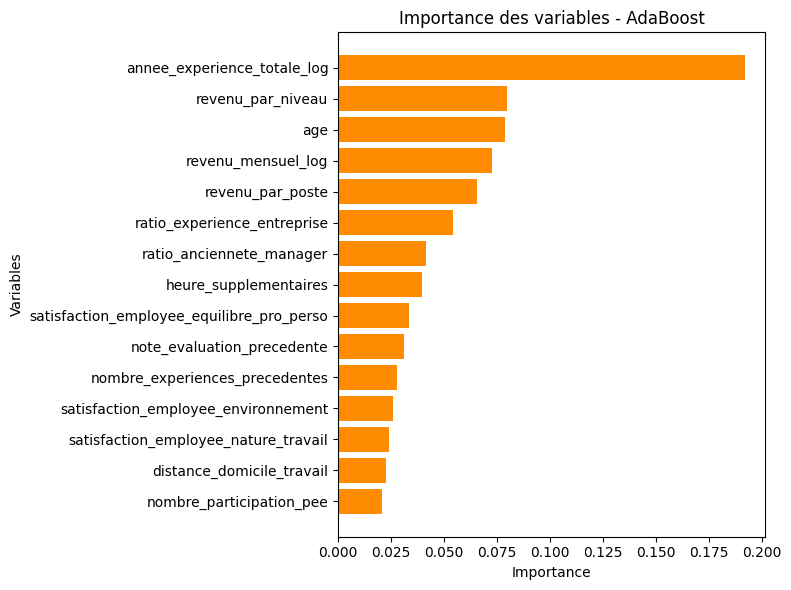

In [11]:
ada_best = ada_results["Best Estimator"]
ada_best.fit(X_model, y_model)

ada_importance = pd.DataFrame({
    "Variable": X_model.columns,
    "Importance": ada_best.feature_importances_,
}).sort_values("Importance", ascending=False)

display(ada_importance.head(15))

top_ada = ada_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_ada["Variable"], top_ada["Importance"], color="darkorange")
plt.title("Importance des variables - AdaBoost")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


**La régression logistique** fait ressortir une structure d’interprétation particulièrement lisible :  
- les heures supplémentaires,  
- l’absence de progression,  
- la mobilité et certains marqueurs de flexibilité professionnelle  
=> Augmentent le risque prédit de départ,  

Tandis que :  
- l’expérience,   
- la satisfaction au travail,   
- la stabilité organisationnelle   
=> Tendent à le réduire.  

**AdaBoost** met en avant un autre type de signal, davantage centré sur les variables de structure de carrière et de rémunération, comme : 
- l’expérience totale, 
- le revenu relatif et l’âge. 

Les deux modèles convergent toutefois sur plusieurs facteurs clés, notamment :  
- les heures supplémentaires,  
- l’expérience et certaines dimensions de satisfaction.  

Ce qui renforce la crédibilité de ces variables comme déterminants importants de la prédiction.

,Variable,Importance Moyenne,Ecart-Type
10,heure_supplementaires,0.244523,0.033938
17,annee_experience_totale_log,0.105785,0.038026
2,nombre_experiences_precedentes,0.095502,0.025797
8,satisfaction_employee_equilibre_pro_perso,0.090398,0.023969
44,poste_regroupe_Consultant,0.084213,0.034943
39,frequence_deplacement_Frequent,0.072176,0.019029
3,satisfaction_employee_environnement,0.056480,0.036263
0,age,0.036069,0.025703
23,ratio_anciennete_poste,0.034260,0.027874
32,statut_marital_Célibataire,0.033901,0.024334


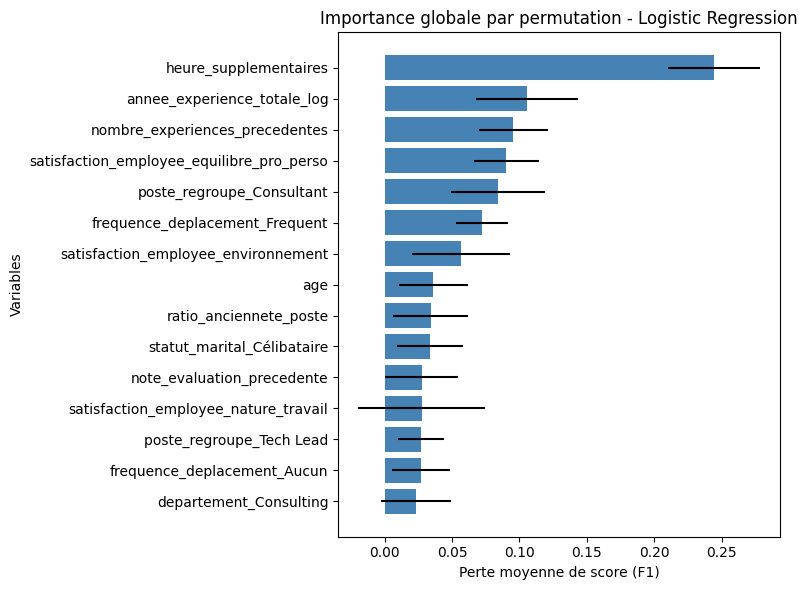

In [12]:
from sklearn.inspection import permutation_importance

logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_train_pr, y_train_pr)

perm = permutation_importance(
    logreg_best,
    X_valid_pr,
    y_valid_pr,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

perm_importance = pd.DataFrame({
    "Variable": X_valid_pr.columns,
    "Importance Moyenne": perm.importances_mean,
    "Ecart-Type": perm.importances_std,
}).sort_values("Importance Moyenne", ascending=False)

display(perm_importance.head(15))

top_perm_importance = perm_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    top_perm_importance["Variable"],
    top_perm_importance["Importance Moyenne"],
    xerr=top_perm_importance["Ecart-Type"],
    color="steelblue",
)
plt.title("Importance globale par permutation - Logistic Regression")
plt.xlabel("Perte moyenne de score (F1)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()


,Variable,Importance Moyenne,Ecart-Type
10,heure_supplementaires,0.215425,0.044173
3,satisfaction_employee_environnement,0.061294,0.021697
41,poste_regroupe_Assistant de Direction,0.033284,0.028570
39,frequence_deplacement_Frequent,0.030895,0.019502
12,nombre_participation_pee,0.017645,0.027906
51,domaine_etude_regroupe_Marketing,0.013580,0.008002
8,satisfaction_employee_equilibre_pro_perso,0.011765,0.029629
35,departement_Commercial,0.005911,0.019820
49,domaine_etude_regroupe_Entrepreunariat,0.005675,0.005165
21,annes_sous_responsable_actuel_log,0.005265,0.009630


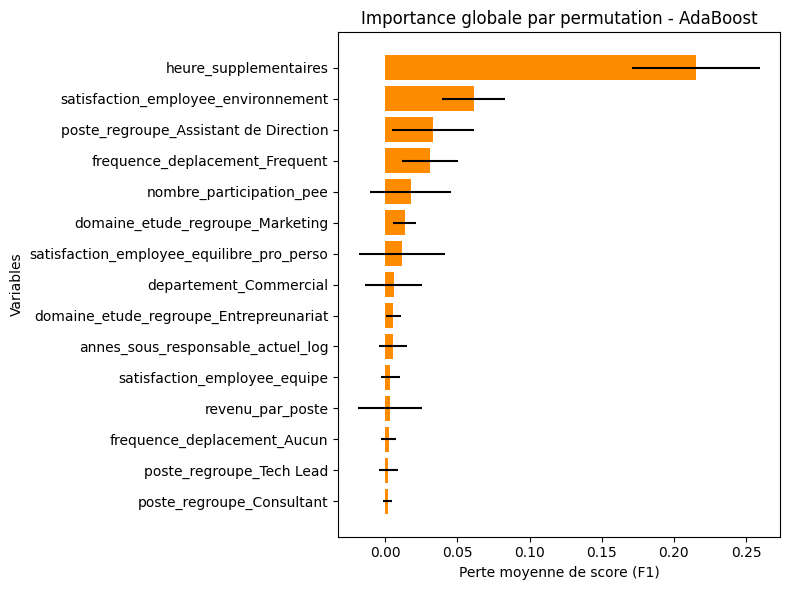

In [13]:
from sklearn.inspection import permutation_importance

ada_best = ada_results["Best Estimator"]
ada_best.fit(X_train_pr, y_train_pr)

perm = permutation_importance(ada_best,X_valid_pr,y_valid_pr,scoring="f1",n_repeats=10,random_state=42,n_jobs=-1,)

perm_importance = pd.DataFrame({
    "Variable": X_valid_pr.columns,
    "Importance Moyenne": perm.importances_mean,
    "Ecart-Type": perm.importances_std,
}).sort_values("Importance Moyenne", ascending=False)

display(perm_importance.head(15))

top_perm_importance = perm_importance.head(15).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(
    top_perm_importance["Variable"],
    top_perm_importance["Importance Moyenne"],
    xerr=top_perm_importance["Ecart-Type"],
    color="darkorange",
)
plt.title("Importance globale par permutation - AdaBoost")
plt.xlabel("Perte moyenne de score (F1)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()



La permutation importance confirme que les `heures supplémentaires` constituent la variable la plus déterminante dans les deux modèles, ce qui renforce fortement la crédibilité de ce facteur.   

La régression logistique apparaît toutefois plus équilibrée dans sa structure prédictive : elle s’appuie sur un ensemble plus large de variables importantes, couvrant :  
-  la charge de travail,  
- l’expérience,  
- la satisfaction,  
- la mobilité et certains marqueurs de profil.  

À l’inverse, AdaBoost semble davantage concentrer sa prédiction sur un nombre plus restreint de variables, avec une dépendance particulièrement forte à quelques signaux dominants et des contributions secondaires plus fragiles.  
Cette lecture conforte l’idée que la régression logistique constitue un modèle plus stable et plus interprétable, tandis qu’AdaBoost reste un challenger crédible mais plus focalisé  

c:\Users\kevin\Desktop\FORMATION AI\01_FORMATION AI ENGINEER\02_PROJETS\04_PROJET 04\01_PREPARATION\PROJET 4\PROJET-4\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


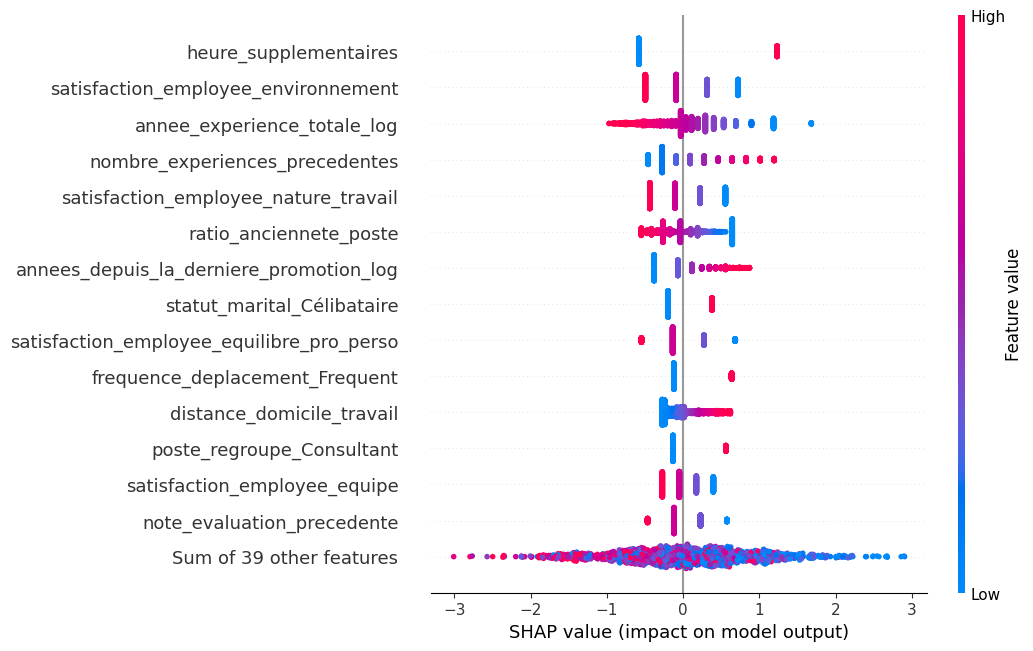

In [14]:
import shap
import pandas as pd

logreg_best = logreg_results["Best Estimator"]
logreg_best.fit(X_model, y_model)

# Recuperation du scaler et du modele lineaire
scaler = logreg_best.named_steps["scaler"]
linear_model = logreg_best.named_steps["model"]

# Transformation + reconstruction en DataFrame pour garder les noms de colonnes
X_model_scaled = pd.DataFrame(
    scaler.transform(X_model),
    columns=X_model.columns,
    index=X_model.index,
)

explainer = shap.LinearExplainer(linear_model, X_model_scaled)
shap_values = explainer(X_model_scaled)

shap.plots.beeswarm(shap_values, max_display=15)


In [23]:
RUN_HEAVY_CELL = False

if RUN_HEAVY_CELL:
    ada_best = ada_results["Best Estimator"]
    ada_best.fit(X_model, y_model)

    # On prend un echantillon de fond plus petit pour limiter le temps de calcul
    background = X_model.sample(100, random_state=42)

    explainer = shap.KernelExplainer(ada_best.predict_proba,background,)

    # On explique un sous-echantillon pour que ce soit calculable
    X_shap_ada = X_model.sample(100, random_state=42)

    shap_values_ada = explainer.shap_values(X_shap_ada)


100%|██████████| 100/100 [22:16<00:00, 13.37s/it]


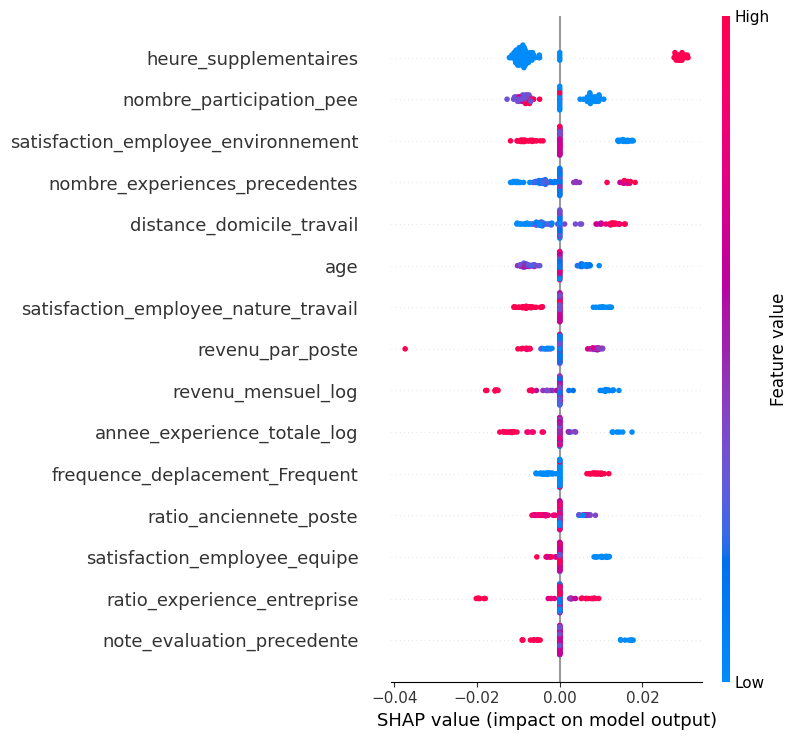

In [29]:
cache = joblib.load("shap_cache_ada.joblib")
X_shap_ada_loaded = cache["X_shap_ada"]
shap_values_ada_loaded = cache["shap_values_ada"]

RUN_HEAVY_CELL = True
shap.summary_plot(shap_values_ada[:, :, 1], X_shap_ada, max_display=15)

#On sauvegarde les sorties car le temps de calcul est long :

import joblib
# Sauvegarde des objets
joblib.dump({"X_shap_ada": X_shap_ada, "shap_values_ada": shap_values_ada},"shap_cache_ada.joblib")

# Sauvegarde du graphique
shap.summary_plot(shap_values_ada, X_shap_ada, show=False)
plt.savefig("shap_summary_ada.png", dpi=150, bbox_inches="tight")
plt.close()


Les beeswarm plots confirment une forte convergence entre la régression logistique et AdaBoost.   

Dans les deux cas, les heures supplémentaires constituent de loin le facteur prédictif le plus structurant : des valeurs élevées augmentent nettement la probabilité prédite de départ. 

Les deux modèles identifient également des signaux cohérents liés à l’expérience, à la satisfaction, à la mobilité, à l’âge et à certaines dimensions de rémunération.  

La régression logistique présente toutefois une structure d’interprétation plus lisible et plus étalée, tandis qu’AdaBoost concentre davantage ses contributions sur un noyau de variables plus restreint.  

Cette convergence renforce la crédibilité des principaux déterminants mis en évidence par les deux approches.


Observation predite = 1 | index = 1326


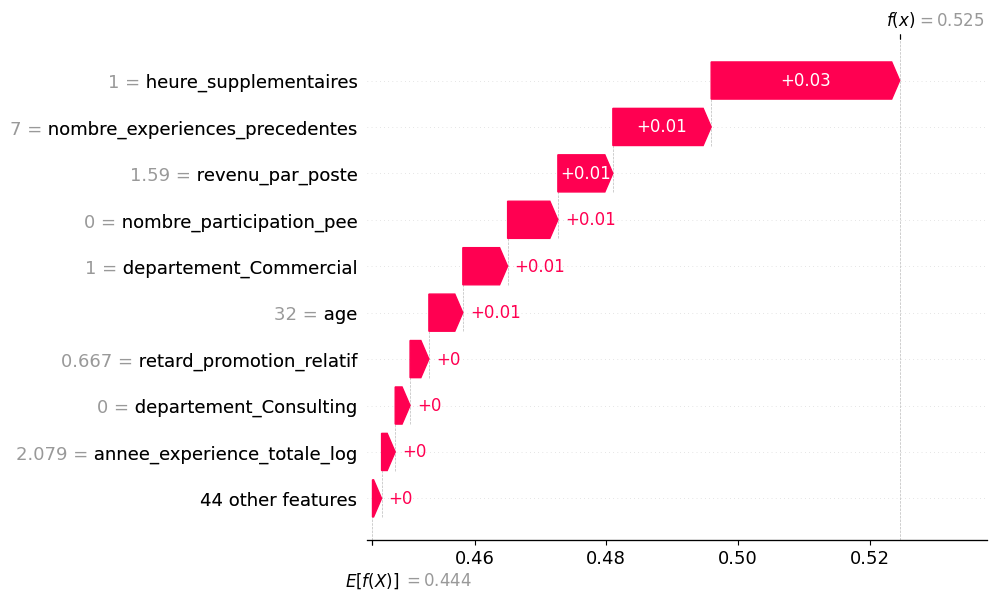


Observation predite = 1 | index = 1436


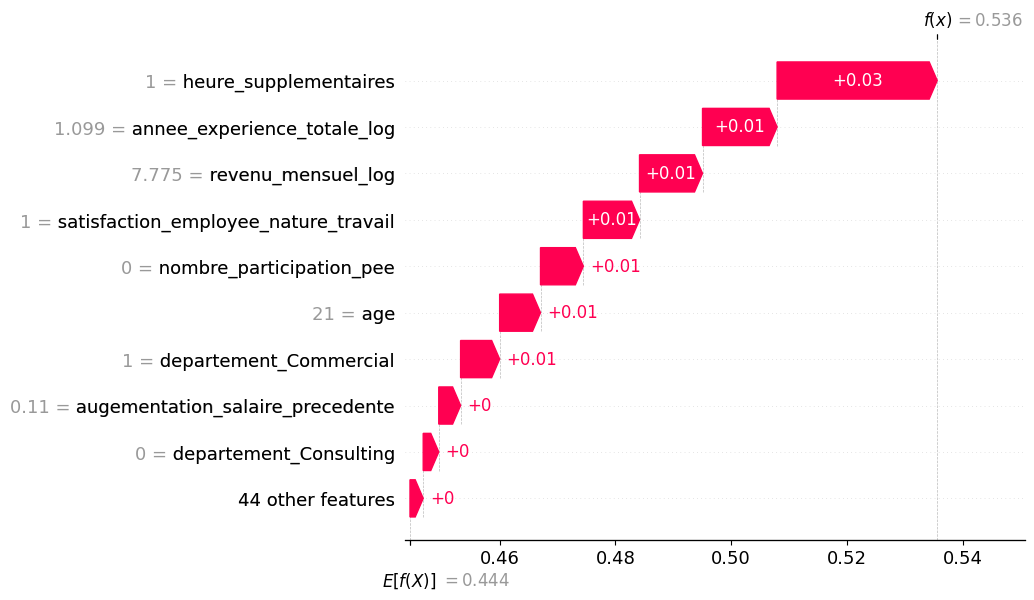


Observation predite = 1 | index = 660


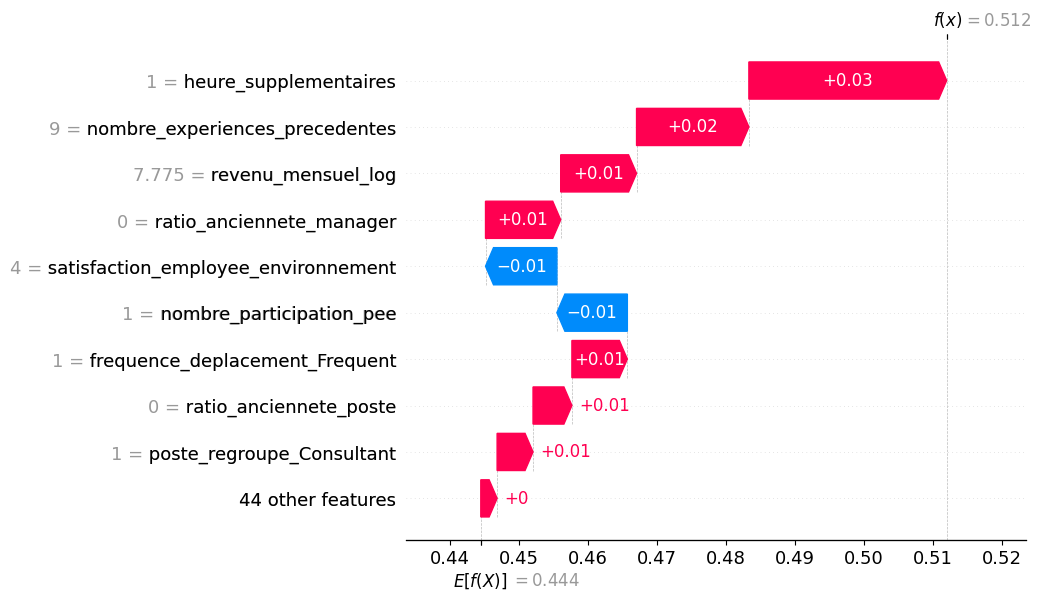


Observation predite = 0 | index = 260


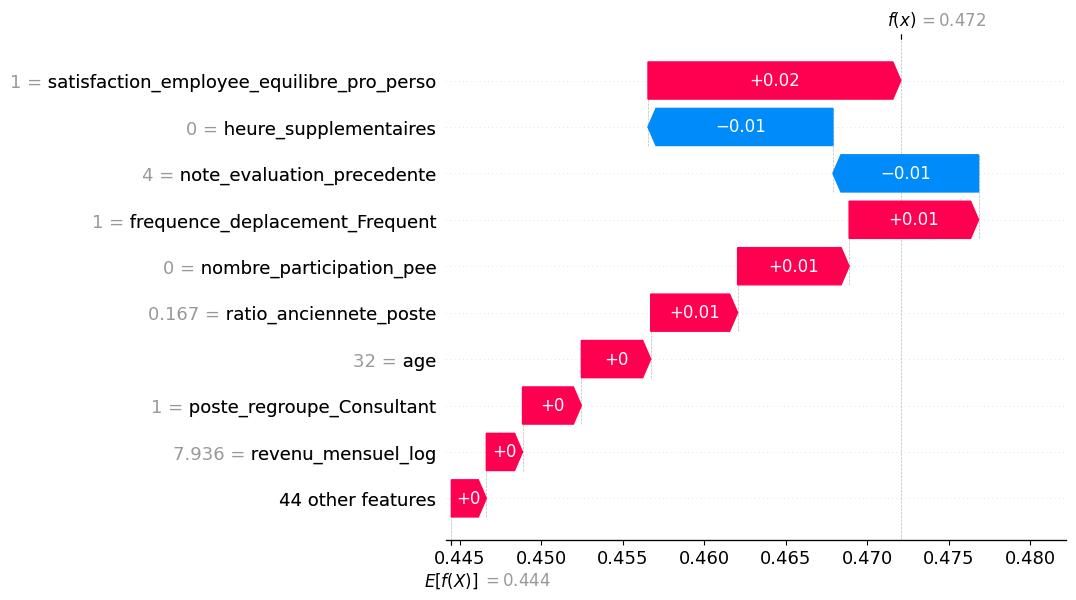


Observation predite = 0 | index = 739


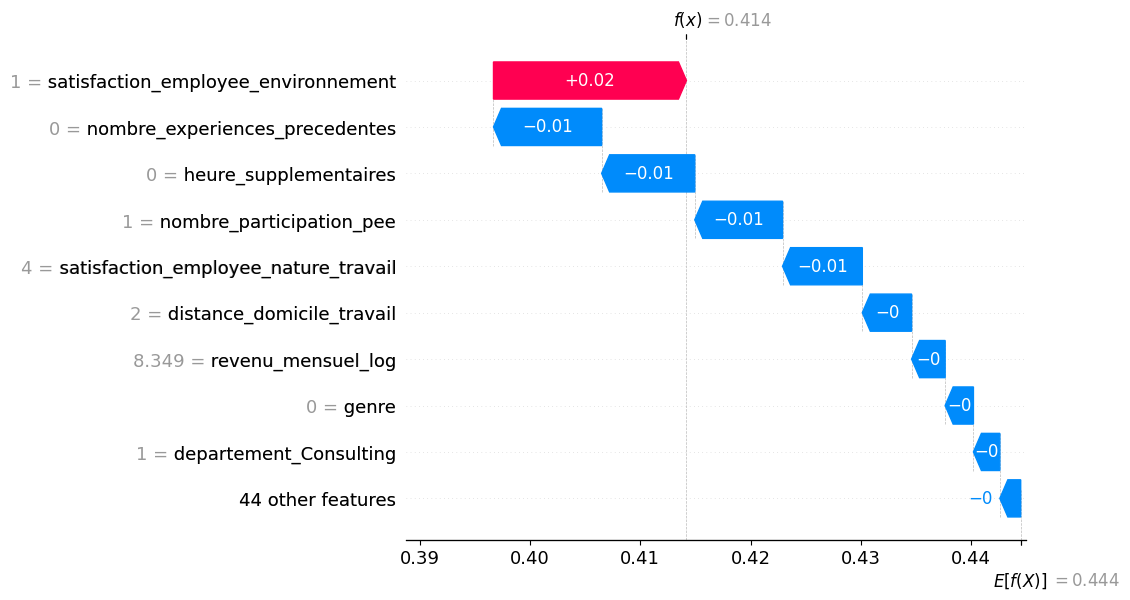


Observation predite = 0 | index = 1103


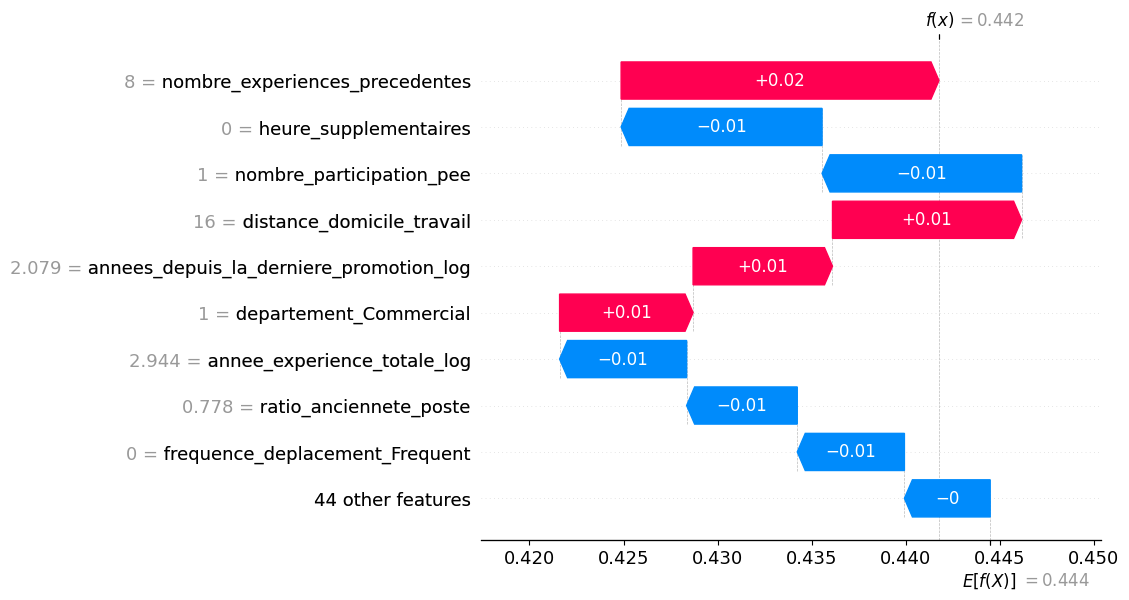

In [31]:
# 1) Prédictions sur le même dataset que SHAP
y_pred_ada_shap = ada_best.predict(X_shap_ada)

idx_pred_1 = X_shap_ada.index[y_pred_ada_shap == 1][:3]
idx_pred_0 = X_shap_ada.index[y_pred_ada_shap == 0][:3]

# 2) Base value classe 1
expected_value = explainer.expected_value
base_value_class_1 = expected_value if np.isscalar(expected_value) else expected_value[1]

# 3) Récupère les SHAP de la classe 1 (gère list ou array)
if isinstance(shap_values_ada, list):
    sv_class_1 = shap_values_ada[1]          # shape: (n_samples, n_features)
else:
    sv_class_1 = shap_values_ada[:, :, 1]    # shape: (n_samples, n_features)

# 4) Waterfalls
for idx in idx_pred_1:
    i = X_shap_ada.index.get_loc(idx)
    print(f"\nObservation predite = 1 | index = {idx}")
    shap.plots.waterfall(
        shap.Explanation(
            values=sv_class_1[i],
            base_values=base_value_class_1,
            data=X_shap_ada.iloc[i],
            feature_names=X_shap_ada.columns,
        ),
        max_display=10,
    )
    plt.savefig(f"waterfall_pred1_{idx}.png", dpi=150, bbox_inches="tight")
    plt.close()

for idx in idx_pred_0:
    i = X_shap_ada.index.get_loc(idx)
    print(f"\nObservation predite = 0 | index = {idx}")
    shap.plots.waterfall(
        shap.Explanation(
            values=sv_class_1[i],
            base_values=base_value_class_1,
            data=X_shap_ada.iloc[i],
            feature_names=X_shap_ada.columns,
        ),
        max_display=10,
    )
    plt.savefig(f"waterfall_pred0_{idx}.png", dpi=150, bbox_inches="tight")
    plt.close()


**Les explications locales montrent que le modèle combine plusieurs signaux modestes pour produire la prédiction finale.**

Les observations prédites en classe 1 (scores f(x) autour de 0.51–0.54) cumulent surtout des contributions positives, en particulier :

- la présence d’heures supplémentaires,
- davantage d’expériences précédentes,
- certains niveaux de revenu,
- et, selon les cas, le département Commercial.

À l’inverse, les observations prédites en classe 0 (scores f(x) autour de 0.41–0.47) présentent davantage de contributions négatives, notamment :

- l’absence d’heures supplémentaires,
- certaines variables d’évaluation/satisfaction,
- la participation au PEE dans certains profils,
- et des effets liés à l’ancienneté ou à la mobilité selon les cas.

Un point important est que les effets unitaires restent souvent modestes (±0.01 à ±0.03) : c’est leur combinaison qui fait basculer la décision, ce qui confirme la logique de compensation entre facteurs.

Maintenant que nous avons regarder des résultats au hasard, nous allons regarder quelques exemples de faux-positifs et de faux-négatifs. 

Seuil AdaBoost utilisé (AdaBoost) : 0.4943
FP: [48, 1165, 1436]
FN: [1444, 1112, 749]


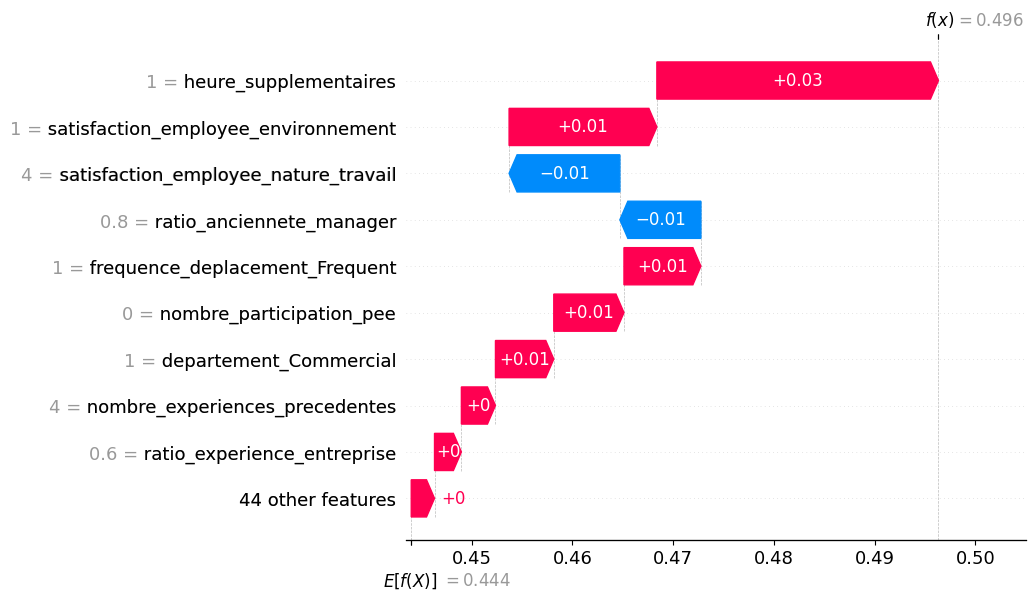

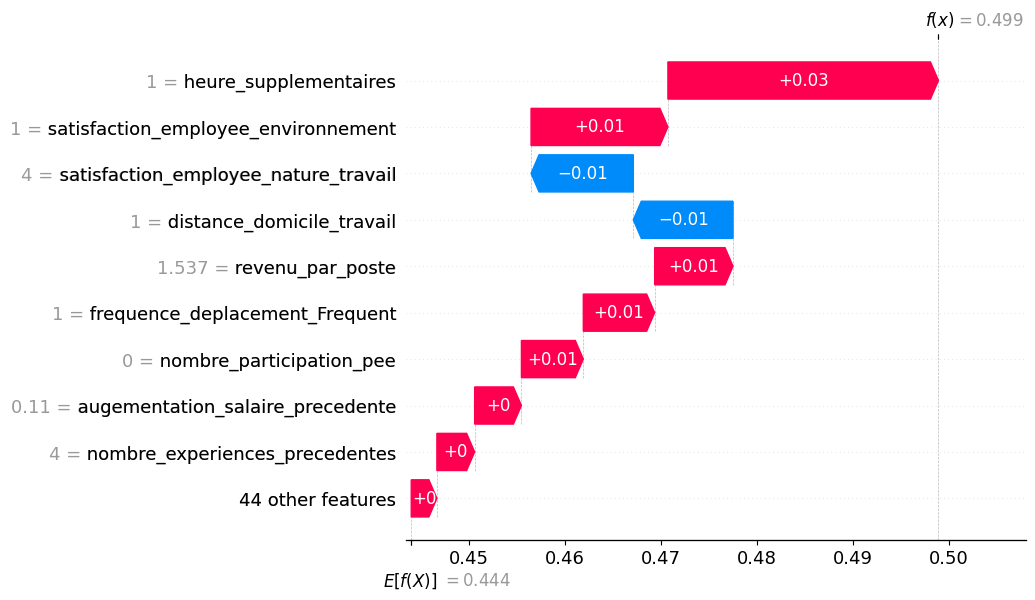

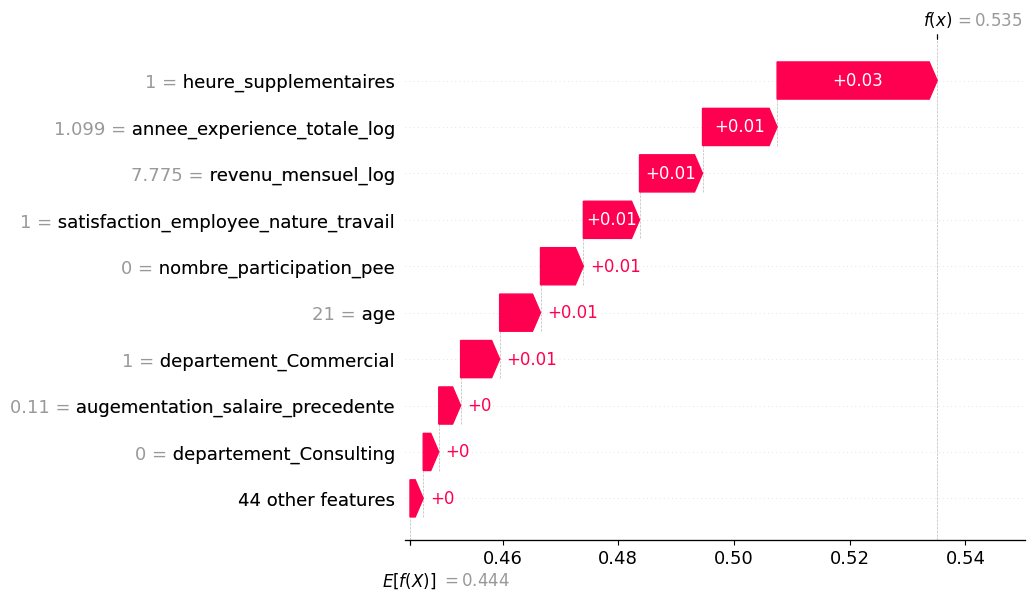

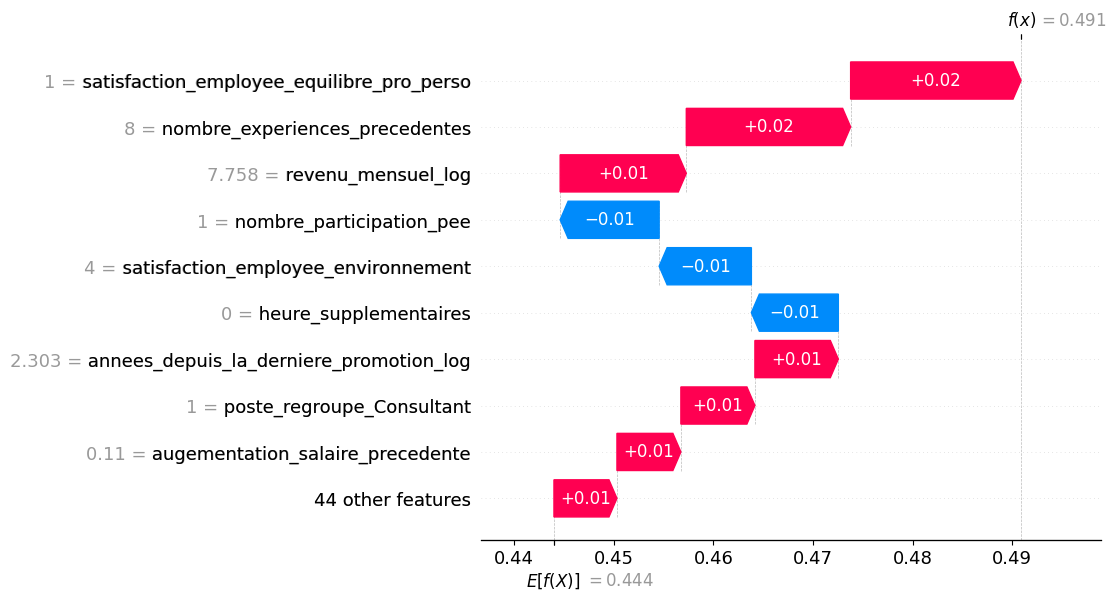

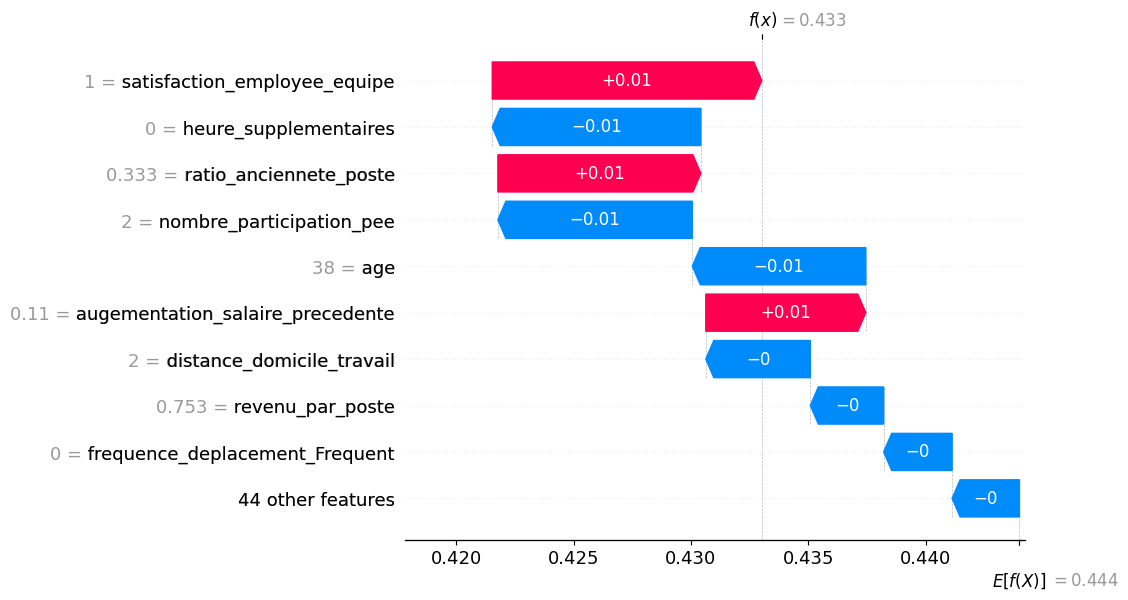

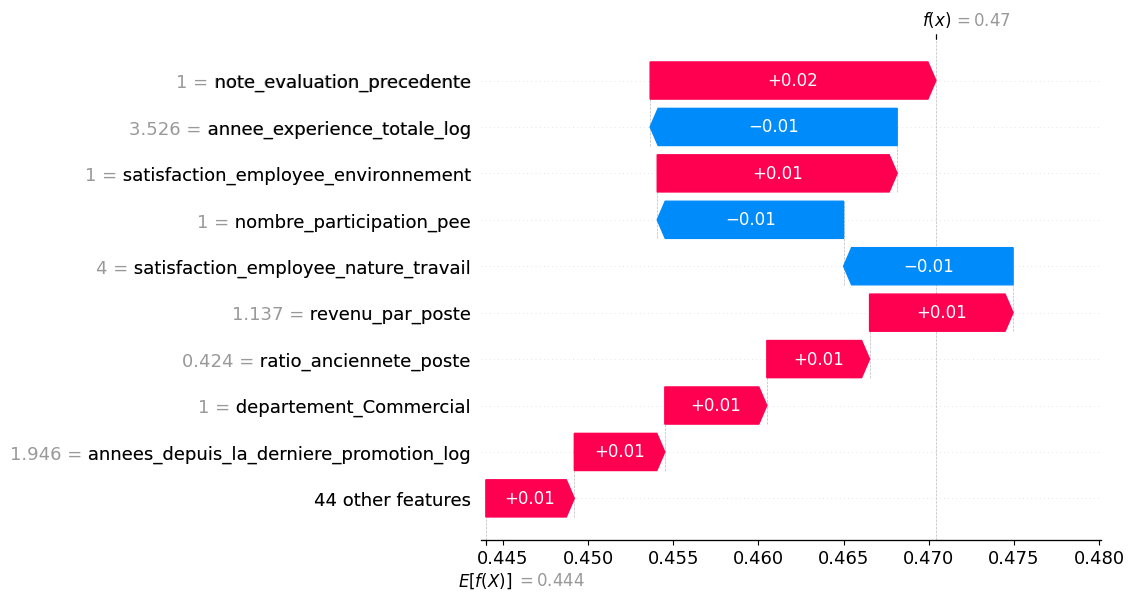

In [46]:
# 1) Récupérer le seuil optimal Ada depuis threshold_results
ada_key = next((k for k in threshold_results.keys() if "ada" in k.lower()), None)
if ada_key is None:
    raise ValueError("Impossible de trouver AdaBoost dans threshold_results.")

threshold = float(threshold_results[ada_key]["Meilleur Seuil"])
print(f"Seuil AdaBoost utilisé ({ada_key}) : {threshold:.4f}")

# 2) FP/FN sur le même échantillon que SHAP (X_shap_ada)
y_true_shap = y_model.loc[X_shap_ada.index].values
proba_shap = ada_best.predict_proba(X_shap_ada)[:, 1]
y_pred_shap = (proba_shap >= threshold).astype(int)

fp_idx = X_shap_ada.index[(y_true_shap == 0) & (y_pred_shap == 1)][:3]
fn_idx = X_shap_ada.index[(y_true_shap == 1) & (y_pred_shap == 0)][:3]

print("FP:", list(fp_idx))
print("FN:", list(fn_idx))

# 3) Valeurs SHAP classe 1 (compatibilité formats)
if isinstance(shap_values_ada, list):
    sv1 = shap_values_ada[1]
elif isinstance(shap_values_ada, shap.Explanation):
    sv1 = shap_values_ada.values[:, :, 1] if shap_values_ada.values.ndim == 3 else shap_values_ada.values
else:
    sv1 = shap_values_ada[:, :, 1] if shap_values_ada.ndim == 3 else shap_values_ada

# 4) Base value
if "explainer" in globals() and hasattr(explainer, "expected_value"):
    ev = explainer.expected_value
    base_value = ev if np.isscalar(ev) else ev[1]
else:
    base_value = 0.444

# 5) Waterfalls FP
for idx in fp_idx:
    i = X_shap_ada.index.get_loc(idx)
    shap.plots.waterfall(
        shap.Explanation(
            values=sv1[i],
            base_values=base_value,
            data=X_shap_ada.iloc[i],
            feature_names=X_shap_ada.columns,
        ),
        max_display=10,
    )
    plt.show()

# 6) Waterfalls FN
for idx in fn_idx:
    i = X_shap_ada.index.get_loc(idx)
    shap.plots.waterfall(
        shap.Explanation(
            values=sv1[i],
            base_values=base_value,
            data=X_shap_ada.iloc[i],
            feature_names=X_shap_ada.columns,
        ),
        max_display=10,
    )
    plt.show()


Les FP/FN observés sont majoritairement des cas proches du seuil, avec des scores f(x) souvent entre 0.43 et 0.50.  

Le modèle arbitre entre signaux opposés:
- heures supplémentaires,   
- satisfaction,  
- expérience,  
- revenu,  
- participation au PEE,  
- ancienneté. 

Aucun facteur unique ne domine systématiquement; ce sont surtout de petites contributions (±0.01 à ±0.03) qui, combinées, font basculer la prédiction.

En pratique, ces erreurs traduisent une zone de décision ambiguë plus qu’un comportement incohérent du modèle.

## Second round de Feature Engineering : 
L’analyse des erreurs suggère que certaines situations restent insuffisamment captées par les variables actuelles, en particulier les cas où plusieurs signaux se compensent ou les départs plus discrets.  

Il apparaît donc pertinent d’enrichir le jeu de données avec de nouvelles variables dérivées visant à mieux retranscrire :  
- les effets de stagnation de carrière,
- de sous-rémunération relative, 
- d’incohérence entre performance et reconnaissance, 
- ainsi que certaines interactions entre charge de travail, ancienneté et position hiérarchique

In [53]:
df_MODEL.columns

Index(['id_employee', 'age', 'genre', 'nombre_experiences_precedentes',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'a_quitte_l_entreprise', 'nombre_participation_pee',
       'nb_formations_suivies', 'distance_domicile_travail',
       'niveau_education', 'revenu_mensuel_log', 'annee_experience_totale_log',
       'annees_dans_l_entreprise_log', 'annees_dans_le_poste_actuel_log',
       'annees_depuis_la_derniere_promotion_log',
       'annes_sous_responsable_actuel_log', 'distance_domicile_travail_classe',
       'ratio_anciennete_poste', 'ratio_anciennete_manager',
       'ratio_experience_entreprise', 'mobilite_interne_potentielle',
       'retard_promotion_relatif', 'revenu_par_niveau

In [60]:
# Copies de travail
X_model_fe = X_model.copy()
X_final_test_fe = X_final_test.copy()

On décide de tester avec les deux modèles shortlistés au début du notebook et en remettant certaines valeurs en échelle normale : 

In [ ]:
# Seuils calcules uniquement sur X_model
note_eval_median = X_model["note_evaluation_actuelle"].median()
age_median = X_model["age"].median()
anciennete_median = X_model["annees_dans_l_entreprise"].median()

# 1. Heures supplementaires sans reconnaissance salariale
X_model["surcharge_sans_reconnaissance"] = (X_model["heure_supplementaires"] * (1 - X_model["augementation_salaire_precedente"]))
X_final_test["surcharge_sans_reconnaissance"] = (X_final_test["heure_supplementaires"] * (1 - X_final_test["augementation_salaire_precedente"]))

# 2. Heures supplementaires sans PEE
X_model["surcharge_sans_PEE"] = (X_model["heure_supplementaires"] * (X_model["nombre_participation_pee"] == 0).astype(int))
X_final_test["surcharge_sans_PEE"] = (X_final_test["heure_supplementaires"] * (X_final_test["nombre_participation_pee"] == 0).astype(int))


# 3. Bonne performance sans reconnaissance globale
X_model["bonne_perf_sans_reconnaissance_globale"] = ((X_model["note_evaluation_actuelle"] >= note_eval_median).astype(int) * (1 - X_model["augementation_salaire_precedente"]) * (X_model["annees_depuis_la_derniere_promotion"] > 0).astype(int))
X_final_test["bonne_perf_sans_reconnaissance_globale"] = ((X_final_test["note_evaluation_actuelle"] >= note_eval_median).astype(int) * (1 - X_final_test["augementation_salaire_precedente"]) * (X_final_test["annees_depuis_la_derniere_promotion"] > 0).astype(int))

# 4. Stagnation manageriale
X_model["stagnation_manageriale"] = (X_model["annes_sous_responsable_actuel"] * (1 - X_model["mobilite_interne_potentielle"]))
X_final_test["stagnation_manageriale"] = (X_final_test["annes_sous_responsable_actuel"] * (1 - X_final_test["mobilite_interne_potentielle"]))

# 5. Sous-positionnement experience / niveau
X_model["sous_positionnement_experience"] = (X_model["annee_experience_totale"] / (X_model["niveau_hierarchique_poste"] + 1))
X_final_test["sous_positionnement_experience"] = (X_final_test["annee_experience_totale"] / (X_final_test["niveau_hierarchique_poste"] + 1))

# 6. Jeune salarie avec heures supplementaires
X_model["jeune_avec_heures_sup"] = ((X_model["age"] <= age_median).astype(int) * X_model["heure_supplementaires"])
X_final_test["jeune_avec_heures_sup"] = ((X_final_test["age"] <= age_median).astype(int) * X_final_test["heure_supplementaires"])

# 7. Anciennete courte
X_model["anciennete_courte"] = (X_model["annees_dans_l_entreprise"] <= anciennete_median).astype(int)
X_final_test["anciennete_courte"] = (X_final_test["annees_dans_l_entreprise"] <= anciennete_median).astype(int)

# 8. Anciennete sans progression
X_model["anciennete_sans_progression"] = (X_model["annees_dans_l_entreprise"] * X_model["retard_promotion_relatif"])
X_final_test["anciennete_sans_progression"] = (X_final_test["annees_dans_l_entreprise"] * X_final_test["retard_promotion_relatif"])

# 9. Enlisement dans le poste
X_model["enlisement_poste"] = (X_model["annees_dans_le_poste_actuel"] * X_model["ratio_anciennete_poste"])
X_final_test["enlisement_poste"] = (X_final_test["annees_dans_le_poste_actuel"] * X_final_test["ratio_anciennete_poste"])

# 10. Anciennete sous le meme manager
X_model["anciennete_sous_meme_manager"] = (X_model["annees_dans_l_entreprise"] * X_model["annes_sous_responsable_actuel"])
X_final_test["anciennete_sous_meme_manager"] = (X_final_test["annees_dans_l_entreprise"] * X_final_test["annes_sous_responsable_actuel"])


In [84]:
num_cols = [
    "age",
    "revenu_mensuel",
    "nombre_experiences_precedentes",
    "annee_experience_totale",
    "annees_dans_l_entreprise",
    "annees_dans_le_poste_actuel",
    "satisfaction_employee_environnement",
    "note_evaluation_precedente",
    "niveau_hierarchique_poste",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
    "note_evaluation_actuelle",
    "nombre_participation_pee",
    "nb_formations_suivies",
    "distance_domicile_travail",
    "niveau_education",
    "annees_depuis_la_derniere_promotion",
    "annes_sous_responsable_actuel",
    "augementation_salaire_precedente",
]

nouvelles_cols = [
    "surcharge_sans_reconnaissance",
    "surcharge_sans_PEE",
    "bonne_perf_sans_reconnaissance_globale",
    "stagnation_manageriale",
    "sous_positionnement_experience",
    "jeune_avec_heures_sup",
    "anciennete_courte",
    "anciennete_sans_progression",
    "enlisement_poste",
    "anciennete_sous_meme_manager",
]


In [85]:
# Sous-ensemble pour l'analyse
corr_candidates = num_cols + nouvelles_cols

# Matrice de corrélation de Pearson
corr_matrix = X_model[corr_candidates].corr(method="pearson")

# Extraction des paires uniques
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack().reset_index())
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Filtre : corrélation absolue > 0.6
strong_corr = (corr_pairs[corr_pairs["abs_correlation"] > 0.6].sort_values("abs_correlation", ascending=False).reset_index(drop=True))
strong_corr[["feature_1", "feature_2", "correlation"]]

,feature_1,feature_2,correlation
0,annees_depuis_la_derniere_promotion,anciennete_sans_progression,0.998239
1,revenu_mensuel,niveau_hierarchique_poste,0.948604
2,annees_dans_le_poste_actuel,enlisement_poste,0.946754
3,annees_dans_l_entreprise,anciennete_sous_meme_manager,0.898214
4,annes_sous_responsable_actuel,anciennete_sous_meme_manager,0.865199
5,stagnation_manageriale,anciennete_sous_meme_manager,-0.847930
6,annee_experience_totale,sous_positionnement_experience,0.801389
7,annee_experience_totale,niveau_hierarchique_poste,0.780844
8,note_evaluation_actuelle,augementation_salaire_precedente,0.775678
9,revenu_mensuel,annee_experience_totale,0.770611


In [86]:
# Variables à supprimer (forte redondance / risque d'overfit)
cols_to_drop = [
    "anciennete_sous_meme_manager",
    "enlisement_poste",
    "stagnation_manageriale",
    "anciennete_courte",
    "surcharge_sans_reconnaissance",
    "anciennete_sans_progression"
]

# Suppression dans train et test
X_model = X_model.drop(columns=cols_to_drop, errors="ignore")
X_final_test = X_final_test.drop(columns=cols_to_drop, errors="ignore")

print("Colonnes supprimées :", cols_to_drop)
print("Nouvelle shape X_model :", X_model.shape)
print("Nouvelle shape X_final_test :", X_final_test.shape)


Colonnes supprimées : ['anciennete_sous_meme_manager', 'enlisement_poste', 'stagnation_manageriale', 'anciennete_courte', 'surcharge_sans_reconnaissance', 'anciennete_sans_progression']
Nouvelle shape X_model : (1323, 57)
Nouvelle shape X_final_test : (147, 57)


In [87]:
X_model.columns

Index(['age', 'genre', 'nombre_experiences_precedentes',
       'satisfaction_employee_environnement', 'note_evaluation_precedente',
       'niveau_hierarchique_poste', 'satisfaction_employee_nature_travail',
       'satisfaction_employee_equipe',
       'satisfaction_employee_equilibre_pro_perso', 'note_evaluation_actuelle',
       'heure_supplementaires', 'augementation_salaire_precedente',
       'nombre_participation_pee', 'nb_formations_suivies',
       'distance_domicile_travail', 'niveau_education',
       'distance_domicile_travail_classe', 'ratio_anciennete_poste',
       'ratio_anciennete_manager', 'ratio_experience_entreprise',
       'mobilite_interne_potentielle', 'retard_promotion_relatif',
       'revenu_par_niveau', 'revenu_par_poste', 'evolution_evaluation',
       'bonne_perf_peu_augmente', 'statut_marital_Célibataire',
       'statut_marital_Divorcé(e)', 'statut_marital_Marié(e)',
       'departement_Commercial', 'departement_Consulting',
       'departement_Ressourc


Logistic Regression
Train | Accuracy: 0.9116 +/- 0.0060 | Precision: 0.8401 +/- 0.0247 | Recall: 0.5563 +/- 0.0253 | F1: 0.6693 +/- 0.0255 | ROC AUC: 0.8853 +/- 0.0062
Test  | Accuracy: 0.8964 +/- 0.0131 | Precision: 0.7965 +/- 0.0992 | Recall: 0.4922 +/- 0.0781 | F1: 0.6023 +/- 0.0595 | ROC AUC: 0.8401 +/- 0.0233


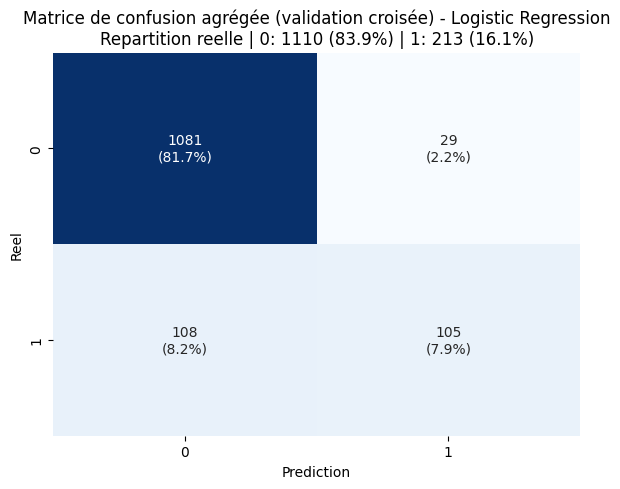


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94      1110
         1.0       0.78      0.49      0.61       213

    accuracy                           0.90      1323
   macro avg       0.85      0.73      0.77      1323
weighted avg       0.89      0.90      0.89      1323


Linear SVC
Train | Accuracy: 0.9102 +/- 0.0065 | Precision: 0.8578 +/- 0.0334 | Recall: 0.5305 +/- 0.0258 | F1: 0.6553 +/- 0.0273 | ROC AUC: 0.8849 +/- 0.0063
Test  | Accuracy: 0.8957 +/- 0.0189 | Precision: 0.8024 +/- 0.1316 | Recall: 0.4783 +/- 0.0786 | F1: 0.5947 +/- 0.0777 | ROC AUC: 0.8394 +/- 0.0213


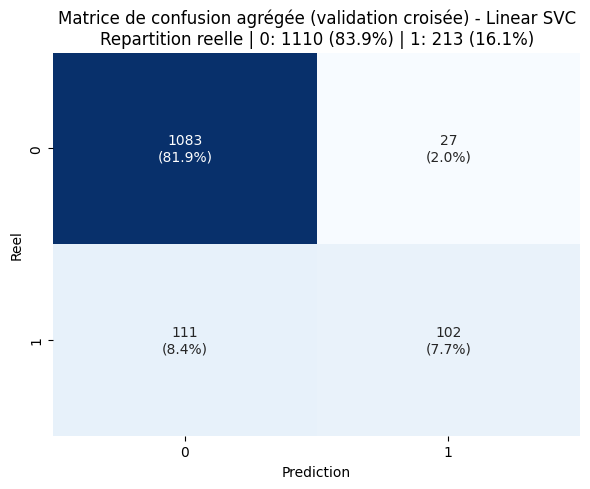


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94      1110
         1.0       0.79      0.48      0.60       213

    accuracy                           0.90      1323
   macro avg       0.85      0.73      0.77      1323
weighted avg       0.89      0.90      0.88      1323


SVC
Train | Accuracy: 0.9318 +/- 0.0024 | Precision: 0.9901 +/- 0.0061 | Recall: 0.5822 +/- 0.0152 | F1: 0.7331 +/- 0.0121 | ROC AUC: 0.9737 +/- 0.0066
Test  | Accuracy: 0.8707 +/- 0.0129 | Precision: 0.7922 +/- 0.1149 | Recall: 0.2669 +/- 0.0797 | F1: 0.3938 +/- 0.0936 | ROC AUC: 0.8286 +/- 0.0132


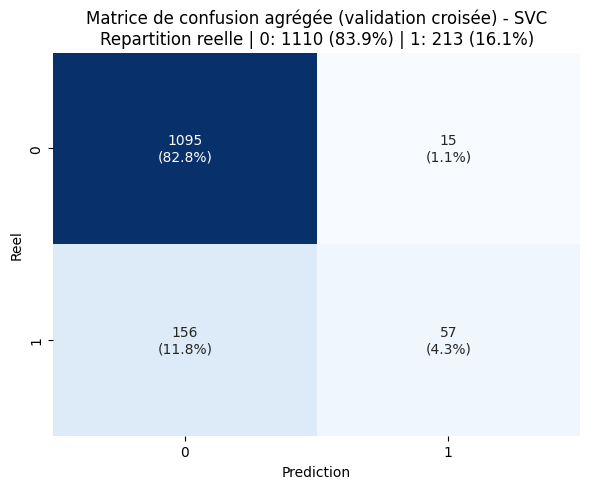


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.99      0.93      1110
         1.0       0.79      0.27      0.40       213

    accuracy                           0.87      1323
   macro avg       0.83      0.63      0.66      1323
weighted avg       0.86      0.87      0.84      1323


KNeighbors Classifier
Train | Accuracy: 0.8864 +/- 0.0039 | Precision: 0.8835 +/- 0.0165 | Recall: 0.3392 +/- 0.0226 | F1: 0.4899 +/- 0.0245 | ROC AUC: 0.9298 +/- 0.0074
Test  | Accuracy: 0.8609 +/- 0.0095 | Precision: 0.7123 +/- 0.0714 | Recall: 0.2300 +/- 0.0581 | F1: 0.3440 +/- 0.0703 | ROC AUC: 0.7015 +/- 0.0344


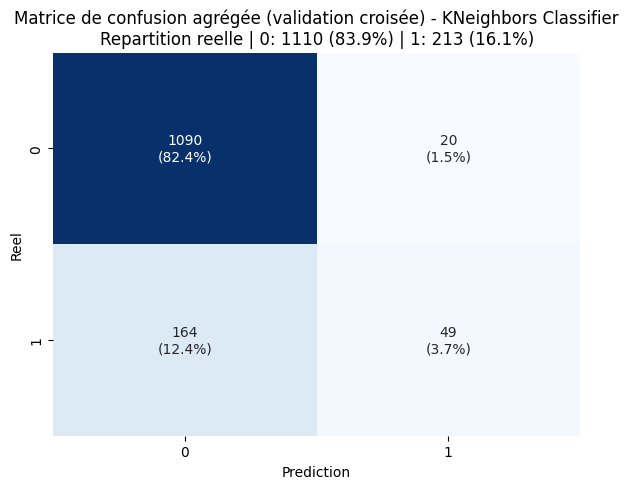


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.98      0.92      1110
         1.0       0.71      0.23      0.35       213

    accuracy                           0.86      1323
   macro avg       0.79      0.61      0.63      1323
weighted avg       0.84      0.86      0.83      1323


Decision Tree
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.7710 +/- 0.0240 | Precision: 0.3181 +/- 0.0429 | Recall: 0.3659 +/- 0.0664 | F1: 0.3384 +/- 0.0508 | ROC AUC: 0.6073 +/- 0.0310


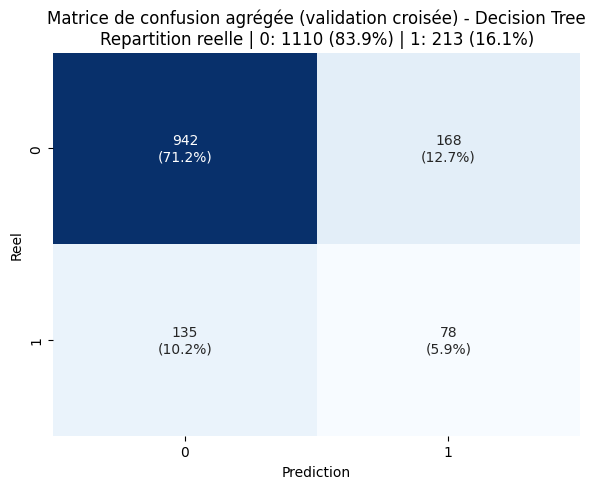


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      1110
         1.0       0.32      0.37      0.34       213

    accuracy                           0.77      1323
   macro avg       0.60      0.61      0.60      1323
weighted avg       0.78      0.77      0.78      1323


Random Forest
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8564 +/- 0.0100 | Precision: 0.6860 +/- 0.1600 | Recall: 0.1969 +/- 0.0689 | F1: 0.3006 +/- 0.0921 | ROC AUC: 0.8086 +/- 0.0339


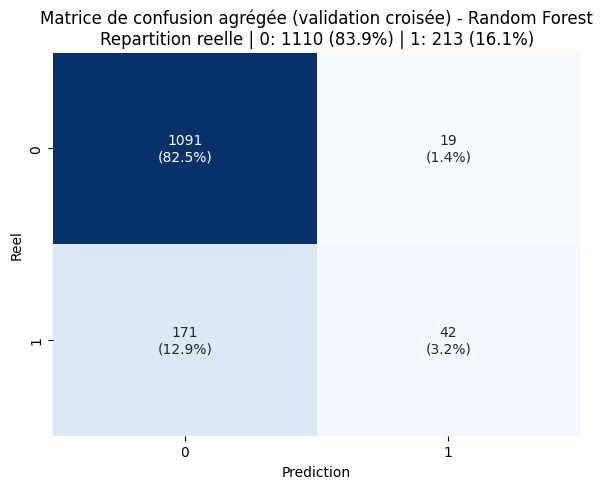


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92      1110
         1.0       0.69      0.20      0.31       213

    accuracy                           0.86      1323
   macro avg       0.78      0.59      0.61      1323
weighted avg       0.84      0.86      0.82      1323


Extra Trees
Train | Accuracy: 1.0000 +/- 0.0000 | Precision: 1.0000 +/- 0.0000 | Recall: 1.0000 +/- 0.0000 | F1: 1.0000 +/- 0.0000 | ROC AUC: 1.0000 +/- 0.0000
Test  | Accuracy: 0.8654 +/- 0.0142 | Precision: 0.7460 +/- 0.1284 | Recall: 0.2248 +/- 0.1008 | F1: 0.3381 +/- 0.1366 | ROC AUC: 0.8093 +/- 0.0281


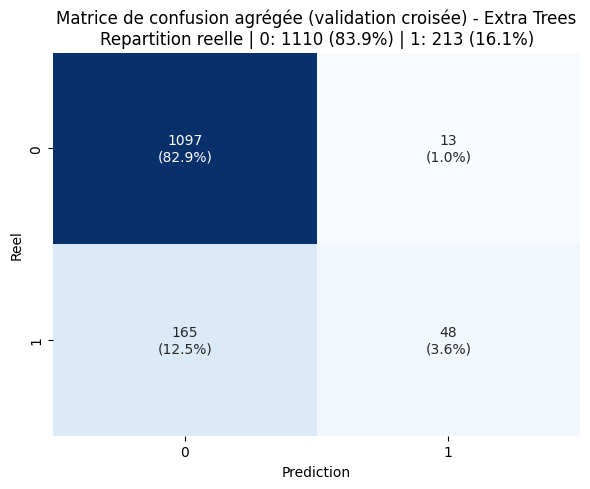


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.87      0.99      0.92      1110
         1.0       0.79      0.23      0.35       213

    accuracy                           0.87      1323
   macro avg       0.83      0.61      0.64      1323
weighted avg       0.86      0.87      0.83      1323


Gradient Boosting
Train | Accuracy: 0.9635 +/- 0.0042 | Precision: 0.9971 +/- 0.0058 | Recall: 0.7758 +/- 0.0278 | F1: 0.8723 +/- 0.0168 | ROC AUC: 0.9931 +/- 0.0018
Test  | Accuracy: 0.8685 +/- 0.0064 | Precision: 0.7089 +/- 0.0597 | Recall: 0.3239 +/- 0.0580 | F1: 0.4392 +/- 0.0487 | ROC AUC: 0.8087 +/- 0.0345


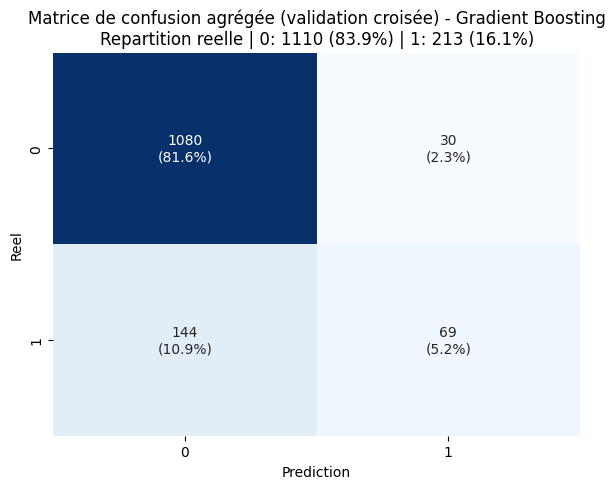


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.93      1110
         1.0       0.70      0.32      0.44       213

    accuracy                           0.87      1323
   macro avg       0.79      0.65      0.68      1323
weighted avg       0.85      0.87      0.85      1323


AdaBoost
Train | Accuracy: 0.8923 +/- 0.0079 | Precision: 0.8438 +/- 0.0129 | Recall: 0.4060 +/- 0.0587 | F1: 0.5458 +/- 0.0549 | ROC AUC: 0.9088 +/- 0.0067
Test  | Accuracy: 0.8753 +/- 0.0066 | Precision: 0.8018 +/- 0.1091 | Recall: 0.3243 +/- 0.0797 | F1: 0.4488 +/- 0.0743 | ROC AUC: 0.8136 +/- 0.0322


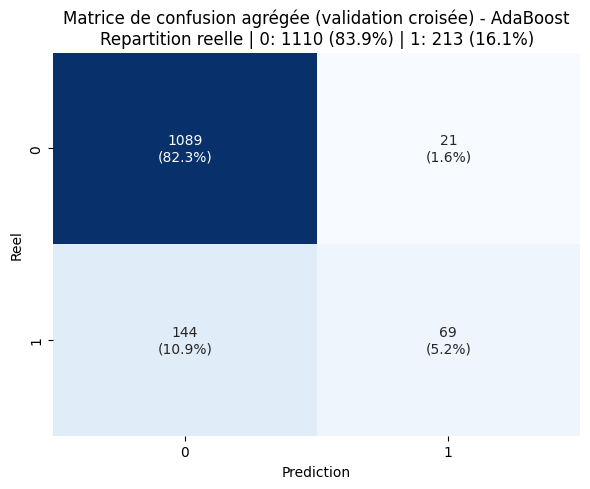


Classification report (out-of-fold):
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93      1110
         1.0       0.77      0.32      0.46       213

    accuracy                           0.88      1323
   macro avg       0.82      0.65      0.69      1323
weighted avg       0.86      0.88      0.85      1323



In [88]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=42)),
    ]),

    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42, dual="auto", max_iter=5000)),
    ]),

    "SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=42)),
    ]),

    "KNeighbors Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42,
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42,
    ),
}


for name, model in models.items():
    Fonctions_MODEL.evaluate_classification_model_cv(model=model,X=X_model,y=y_model,cv=5,stratify=True,model_name=name,)

In [74]:
#On vient maintenant régler les hyperparamètres (orienté recall)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=10000, random_state=42)),
    ]),
    "Linear SVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(max_iter=100000, random_state=42, dual="auto")),
    ]),
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 3, 10, 30],
        "model__class_weight": [
            "balanced",
            {0: 1, 1: 1.5},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 4},
        ],
        "model__solver": ["lbfgs"],
    },
    "Linear SVC": {
        "model__C": [0.01, 0.1, 1, 3, 10, 30],
        "model__loss": ["squared_hinge"],
        "model__class_weight": [
            "balanced",
            {0: 1, 1: 1.5},
            {0: 1, 1: 2},
            {0: 1, 1: 3},
            {0: 1, 1: 4},
        ],
    },
}

results = {}
for name, model in models.items():
    results[name] = Fonctions_MODEL.optimize_classification_hyperparameters(
        model=model,
        param_grid=param_grids[name],
        X=X_model,
        y=y_model,
        cv=5,
        scoring="recall",   # <- objectif recall
        stratify=True,
        search_type="grid",
        model_name=name,
    )



Logistic Regression
GridSearchCV | Scoring : recall | Meilleur score CV : 0.7186
Meilleurs hyperparametres : {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'lbfgs'}

Linear SVC
GridSearchCV | Scoring : recall | Meilleur score CV : 0.7183
Meilleurs hyperparametres : {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__loss': 'squared_hinge'}



Logistic Regression
Precision moyenne : 0.6732 | Meilleur seuil (max F1) : 0.6445
Au seuil 0.6445 | Precision test : 0.7500 | Recall test : 0.6279 | F1 test : 0.6835


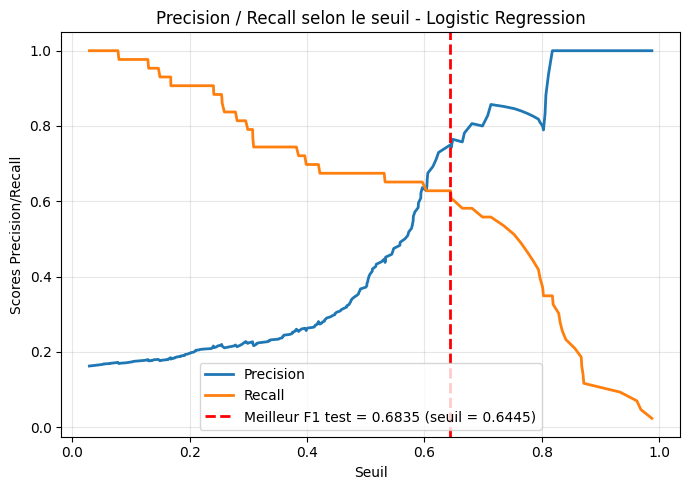


Linear SVC
Precision moyenne : 0.6690 | Meilleur seuil (max F1) : 0.3513
Au seuil 0.3513 | Precision test : 0.7714 | Recall test : 0.6279 | F1 test : 0.6923


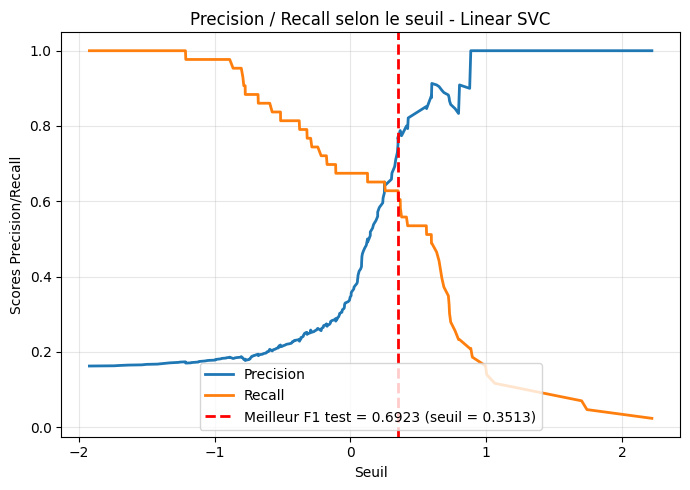


Seuils optimaux trouvés :
Logistic Regression -> seuil=0.6445 | Precision=0.7500 | Recall=0.6279 | F1=0.6835
Linear SVC -> seuil=0.3513 | Precision=0.7714 | Recall=0.6279 | F1=0.6923


In [76]:
# Modèles optimisés pour le recall
models = {
    "Logistic Regression": results["Logistic Regression"]["Best Estimator"],
    "Linear SVC": results["Linear SVC"]["Best Estimator"],
}

# Split interne pour régler le seuil (sans toucher au test final)
X_train_pr, X_valid_pr, y_train_pr, y_valid_pr = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

threshold_results = {}

for name, model in models.items():
    threshold_results[name] = Fonctions_MODEL.evaluate_precision_recall_threshold(
        model=model,
        X_train=X_train_pr,
        y_train=y_train_pr,
        X_eval=X_valid_pr,
        y_eval=y_valid_pr,
        model_name=name,
        plot_curve=True,
    )

print("\nSeuils optimaux trouvés :")
for name, res in threshold_results.items():
    print(
        f"{name} -> seuil={res['Meilleur Seuil']:.4f} | "
        f"Precision={res['Precision Test Au Meilleur Seuil']:.4f} | "
        f"Recall={res['Recall Test Au Meilleur Seuil']:.4f} | "
        f"F1={res['F1 Test Au Meilleur Seuil']:.4f}"
    )


#### Après optimisation orientée recall puis réglage du seuil, Linear SVC est retenu comme meilleur compromis.

#### Au seuil 0.3513, il atteint une précision de 0.7714, un rappel de 0.6279 et un F1 de 0.6923, supérieur à la régression logistique (F1 = 0.6835).

#### Les deux modèles détectent autant de cas positifs (recall identique), mais Linear SVC génère moins de fausses alertes (précision plus élevée).

## Test de performance final

On passe au test final sur le dataset mis de côté au départ. 

In [81]:
lr = results["Logistic Regression"]["Best Estimator"]; 
Xtr,Xv,ytr,yv = train_test_split(X_model,y_model,test_size=0.2,random_state=42,stratify=y_model)
lr.fit(Xtr,ytr); pv = lr.predict_proba(Xv)[:,1]

ths = np.linspace(0.01,0.99,300); 
t = ths[np.argmax([f1_score(yv,(pv>=x).astype(int)) for x in ths])]
lr.fit(X_model,y_model); pt = lr.predict_proba(X_final_test)[:,1]; yp = (pt>=t).astype(int)

print(f"Seuil={t:.4f} | Acc={accuracy_score(y_final_test,yp):.4f} | Prec={precision_score(y_final_test,yp):.4f} | Rec={recall_score(y_final_test,yp):.4f} | F1={f1_score(y_final_test,yp):.4f} | AUC={roc_auc_score(y_final_test,pt):.4f}")
print(confusion_matrix(y_final_test, yp))
print(classification_report(y_final_test, yp, digits=4))


Seuil=0.6262 | Acc=0.8027 | Prec=0.4000 | Rec=0.4167 | F1=0.4082 | AUC=0.7961
[[108  15]
 [ 14  10]]
              precision    recall  f1-score   support

           0     0.8852    0.8780    0.8816       123
           1     0.4000    0.4167    0.4082        24

    accuracy                         0.8027       147
   macro avg     0.6426    0.6474    0.6449       147
weighted avg     0.8060    0.8027    0.8043       147

